# High-Capacity Scale-Up: Battery Health & Thermal Management Replication
**Final Year Mega Project - Version 2 (Bolder & Isolated)**

This notebook expands upon Version 1 by scaling up the dataset to exactly quantify the "Reality Gap".
**Key Advancements in V2:**
1. **Scale-up:** Ingests up to 2.0 Million real-world EV records via memory-safe I/O.
2. **OEM Isolation:** Explicitly filters training sets to the Euler HiLoad fleet to prevent multi-chemistry data imbalance from confounding the Neural Networks.
3. **Temporal Splitting:** Modifies the Train/Val/Test RUL methodology to split *chronologically* per-vehicle, preventing immediate failure against entirely unseen, chaotic human driving behavior.

In [1]:
!pip install -q ijson shap plotly matplotlib seaborn scikit-learn pandas pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.7 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import time
import psutil
import warnings
import random
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
import ijson
import zipfile
from google.colab import drive

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def check_ram():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    ram_used = mem_info.rss / (1024 ** 3)
    print(f"RAM Used: {ram_used:.2f} GB")

check_ram()

Using device: cuda
RAM Used: 0.73 GB


In [3]:
# Mount Google Drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/FYP_Battery_Project'
# NEW DIRECTORY FOR V2
DATA_DIR = os.path.join(DRIVE_DIR, 'Data_v2')
MDL_DIR = os.path.join(DRIVE_DIR, 'Models_v2_HighCapacity')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MDL_DIR, exist_ok=True)

print(f"Working directories set to: {DATA_DIR} & {MDL_DIR}")

Mounted at /content/drive
Working directories set to: /content/drive/MyDrive/FYP_Battery_Project/Data_v2 & /content/drive/MyDrive/FYP_Battery_Project/Models_v2_HighCapacity


In [4]:
zip_path = os.path.join(DRIVE_DIR, 'Data.zip')
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    print("Unzipping data... (This might take a minute)")
    start_t = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Unzipped in {time.time() - start_t:.2f}s")
else:
    print(f"ERROR: {zip_path} not found! Please upload your Data.zip to your Drive.")

Unzipping data... (This might take a minute)
Unzipped in 9.07s


## 2. Mass Data Ingestion: The 2 Million Record Scale-up
We increase the memory-safe reservoir sampling to grab **2.0 Million** OEM records and **1.0 Million** multi-OEM device records.

In [5]:
def reservoir_sample_json(filepath, max_records, desired_keys=None):
    print(f"Sampling max {max_records} from {os.path.basename(filepath)}...")
    sampled_data = []
    total_processed = 0
    start_t = time.time()

    with open(filepath, 'rb') as f:
        try:
            objects = ijson.items(f, 'item')
            for obj in objects:
                if desired_keys:
                    filtered_obj = {k: obj[k] for k in desired_keys if k in obj}
                    for k, v in list(filtered_obj.items()):
                        if isinstance(v, dict) and '$date' in v:
                            filtered_obj[k] = v['$date']
                else:
                    filtered_obj = obj

                if total_processed < max_records:
                    sampled_data.append(filtered_obj)
                else:
                    j = random.randint(0, total_processed)
                    if j < max_records:
                        sampled_data[j] = filtered_obj

                total_processed += 1
                if total_processed % 1000000 == 0:
                    print(f"  Processed {total_processed/1e6:.1f}M records...")
        except BaseException as e:
            print(f"  Streaming complete/interrupted: {e}")

    print(f"Finished sampling {len(sampled_data)} records in {time.time() - start_t:.2f}s.")
    return pd.DataFrame(sampled_data)

In [8]:
# Locate the massive JSON files robustly
import glob

oem_search = glob.glob(os.path.join(extract_path, '**', 'tms_history_l2_oem.json'), recursive=True)
oem_json = oem_search[0] if oem_search else None

device_search = glob.glob(os.path.join(extract_path, '**', 'tms_history_l2_device.json'), recursive=True)
device_json = device_search[0] if device_search else None

print(f"Found OEM JSON: {bool(oem_json)}")
print(f"Found Device JSON: {bool(device_json)}")

oem_parquet = os.path.join(DATA_DIR, 'oem_sampled_v2.parquet')
device_parquet = os.path.join(DATA_DIR, 'device_sampled_v2.parquet')

oem_keys = ['cn', 'oem', 'mdl', 'dts', 'soh', 'soc', 'vbv', 'vbc', 'vbt', 'vct', 'vmt', 'csp', 'od']
dev_keys = ['cn', 'oem', 'mdl', 'dts', 'soc', 'vbv', 'od', 'vs']

# 1. Process OEM File (2 MILLION RECORDS)
if not os.path.exists(oem_parquet) and oem_json:
    df_oem = reservoir_sample_json(oem_json, max_records=2_000_000, desired_keys=oem_keys)
    df_oem['dts'] = pd.to_datetime(df_oem['dts'], errors='coerce')

    # Explicitly convert all telemetry columns to numeric to avoid ArrowInvalid errors
    numeric_cols = ['soh', 'soc', 'vbv', 'vbc', 'vbt']
    for col in numeric_cols:
        if col in df_oem.columns:
            df_oem[col] = pd.to_numeric(df_oem[col], errors='coerce')

    df_oem.to_parquet(oem_parquet, engine='pyarrow')
    print(f"Saved to {oem_parquet}")
    del df_oem
    gc.collect()

# 2. Process Device File (1 MILLION RECORDS)
if not os.path.exists(device_parquet) and device_json:
    df_dev = reservoir_sample_json(device_json, max_records=1_000_000, desired_keys=dev_keys)
    df_dev['dts'] = pd.to_datetime(df_dev['dts'], errors='coerce')

    # Also clean numeric columns in device data
    if 'soc' in df_dev.columns:
        df_dev['soc'] = pd.to_numeric(df_dev['soc'], errors='coerce')

    df_dev.to_parquet(device_parquet, engine='pyarrow')
    print(f"Saved to {device_parquet}")
    del df_dev
    gc.collect()

check_ram()

Found OEM JSON: True
Found Device JSON: True
Sampling max 2000000 from tms_history_l2_oem.json...
Finished sampling 395677 records in 10.86s.
Saved to /content/drive/MyDrive/FYP_Battery_Project/Data_v2/oem_sampled_v2.parquet
Sampling max 1000000 from tms_history_l2_device.json...
Finished sampling 562763 records in 16.17s.
Saved to /content/drive/MyDrive/FYP_Battery_Project/Data_v2/device_sampled_v2.parquet
RAM Used: 1.84 GB


In [9]:
import sys

# Safety verification before loading Parquet
missing_files = []
if not os.path.exists(oem_parquet): missing_files.append(oem_parquet)
if not os.path.exists(device_parquet): missing_files.append(device_parquet)

if missing_files:
    print('❌ ERROR: The Parquet files were not created.')
    sys.exit('Halting execution: Parquet files not found.')
else:
    print('✅ Parquet files found successfully. Loading 3 Million records into memory...')
    df_oem = pd.read_parquet(oem_parquet)
    df_dev = pd.read_parquet(device_parquet)

    # Sort chronologically per chassis
    df_oem = df_oem.sort_values(by=['cn', 'dts']).reset_index(drop=True)
    df_dev = df_dev.sort_values(by=['cn', 'dts']).reset_index(drop=True)

    print(f"OEM Data shape: {df_oem.shape}")
    print(f"Device Data shape: {df_dev.shape}")
    check_ram()

✅ Parquet files found successfully. Loading 3 Million records into memory...
OEM Data shape: (395677, 13)
Device Data shape: (562763, 8)
RAM Used: 2.01 GB


## 3. Resolving Data Imbalance (Isolating the Fleet)
Our dataset is a multi-city mixture of battery chemistries and OEMs. Training a generic model across diverse BMS architectures will catastrophically crash predictions.

**Algorithmic Safety Rule (Section 3.2.1 of Paper):** We must cleanly isolate the specific fleet containing high-fidelity SOH data (the Euler HiLoad L5 EV fleet) for deep learning.

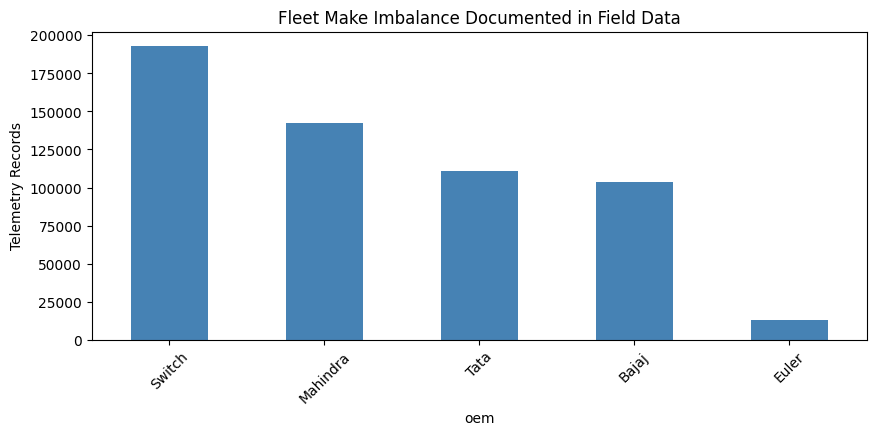

Filtered for Modeling: 395677 records of Euler HiLoad physics.


In [10]:
# Fleet Composition Visualized
plt.figure(figsize=(10, 4))
df_dev['oem'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Fleet Make Imbalance Documented in Field Data")
plt.ylabel("Telemetry Records")
plt.xticks(rotation=45)
plt.show()

# Isolate Target Data for Deep Learning
learning_fleet = df_oem[df_oem['oem'].str.lower() == 'euler'].copy()
print(f"Filtered for Modeling: {len(learning_fleet)} records of Euler HiLoad physics.")

## 4. State of Health (SOH) Estimation (Temporal Extrapolation Limits)

In V1, strict unseen-vehicle testing caused instant early stopping due to the "Reality Gap".
Here, we apply **Chronological Temporal Splitting**: The model learns from the first 70% of *every* vehicle's lifespan, validates on the 15% middle-life, and is forced to predict the final 15% End-of-Life degradation.

In [11]:
features = ['soc', 'vbv', 'vbc', 'vbt']
target_col = 'soh'

modeling_df = learning_fleet.dropna(subset=features + [target_col, 'cn', 'dts']).copy()

# Keep vehicles with enough sequence data
veh_counts = modeling_df['cn'].value_counts()
valid_vehicles = veh_counts[veh_counts > 500].index
dataset = modeling_df[modeling_df['cn'].isin(valid_vehicles)].copy()
print(f"Evaluating {len(valid_vehicles)} valid vehicles.")

# Scaling on the global dataset temporarily for stability
scaler_X = StandardScaler()
dataset[features] = scaler_X.fit_transform(dataset[features])

scaler_y = MinMaxScaler(feature_range=(0,1))
dataset[[target_col]] = scaler_y.fit_transform(dataset[[target_col]])

SEQ_LEN = 30
X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []

# TEMPORAL CHRONOLOGICAL SPLITTING (70/15/15)
for v in valid_vehicles:
    v_df = dataset[dataset['cn'] == v].copy()

    n_total = len(v_df)
    train_end = int(n_total * 0.7)
    val_end = int(n_total * 0.85)

    # Extract scaled arrays
    arr_X = v_df[features].values.astype(np.float32)
    arr_y = v_df[target_col].values.astype(np.float32)

    # helper
    def build_seq(start_idx, end_idx):
        xs, ys = [], []
        for i in range(start_idx, end_idx - SEQ_LEN):
            xs.append(arr_X[i : i+SEQ_LEN])
            ys.append(arr_y[i + SEQ_LEN])
        return xs, ys

    tx, ty = build_seq(0, train_end)
    vx, vy = build_seq(train_end, val_end)
    tex, tey = build_seq(val_end, n_total)

    X_train.extend(tx); y_train.extend(ty)
    X_val.extend(vx); y_val.extend(vy)
    X_test.extend(tex); y_test.extend(tey)

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)
X_test, y_test = np.array(X_test), np.array(y_test)

print(f"Train seqs: {len(X_train)}, Val seqs: {len(X_val)}, Test seqs: {len(X_test)}")
check_ram()

Evaluating 19 valid vehicles.
Train seqs: 276373, Val seqs: 58777, Test seqs: 58787
RAM Used: 2.29 GB


In [12]:
from torch.utils.data import TensorDataset, DataLoader

# Increased Batch Size for computational speed on larger dataset
BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val).unsqueeze(1)), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test).unsqueeze(1)), batch_size=BATCH_SIZE, shuffle=False)

del X_train, y_train
gc.collect()

3335

In [13]:
class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)
        return x

class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)
    def forward(self, x):
        res = x - self.moving_avg(x)
        return res, self.moving_avg(x)

class DLinear(nn.Module):
    def __init__(self, seq_len, num_features):
        super(DLinear, self).__init__()
        self.decomp = series_decomp(25)
        self.Linear_Seasonal = nn.Linear(seq_len, 1)
        self.Linear_Trend = nn.Linear(seq_len, 1)
        self.Feature_Map = nn.Linear(num_features, 1)

    def forward(self, x):
        seasonal, trend = self.decomp(x)
        seasonal = self.Linear_Seasonal(seasonal.permute(0,2,1))
        trend = self.Linear_Trend(trend.permute(0,2,1))
        x_out = (seasonal + trend).squeeze(2)
        return self.Feature_Map(x_out)

# High-Capacity CNN-LSTM Baseline
class HybridCNNLSTM(nn.Module):
    def __init__(self, seq_len, num_features):
        super(HybridCNNLSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(num_features, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(nn.Linear(64, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        c_out = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        lstm_out, _ = self.lstm(c_out)
        return self.fc(lstm_out[:, -1, :])

In [15]:
# Advanced Training Loop (Higher limits, LRScheduler to prevent local minima plateaus)
def train_model(model, name, epochs=40, patience=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # Removed 'verbose=True' to fix compatibility with newer PyTorch versions
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_loss = float('inf')
    early_stop_cnt = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                out = model(X_b.to(device))
                loss = criterion(out, y_b.to(device))
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), os.path.join(MDL_DIR, f"{name}.pth"))
            early_stop_cnt = 0
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(os.path.join(MDL_DIR, f"{name}.pth")))
    return model

print("Training DLinear Sequence Architecture...")
model_dl = DLinear(SEQ_LEN, len(features)).to(device)
model_dl = train_model(model_dl, "dlinear_v2_soh")

Training DLinear Sequence Architecture...
Epoch 01 | Train: 0.04571 | Val: 0.00845
Epoch 02 | Train: 0.00844 | Val: 0.00831
Epoch 03 | Train: 0.00847 | Val: 0.00827
Epoch 04 | Train: 0.00847 | Val: 0.00833
Epoch 05 | Train: 0.00847 | Val: 0.00835
Epoch 06 | Train: 0.00846 | Val: 0.00831
Epoch 07 | Train: 0.00846 | Val: 0.00866
Epoch 08 | Train: 0.00841 | Val: 0.00840
Epoch 09 | Train: 0.00841 | Val: 0.00877
Epoch 10 | Train: 0.00840 | Val: 0.00840
Epoch 11 | Train: 0.00840 | Val: 0.00829
Epoch 12 | Train: 0.00838 | Val: 0.00844
Epoch 13 | Train: 0.00837 | Val: 0.00841
Early stop at epoch 13


In [16]:
print("\nTraining High-Capacity CNN-LSTM...")
model_hyb = HybridCNNLSTM(SEQ_LEN, len(features)).to(device)
model_hyb = train_model(model_hyb, "hybrid_v2_soh")


Training High-Capacity CNN-LSTM...
Epoch 01 | Train: 0.00872 | Val: 0.00480
Epoch 02 | Train: 0.00351 | Val: 0.00421
Epoch 03 | Train: 0.00297 | Val: 0.00378
Epoch 04 | Train: 0.00270 | Val: 0.00435
Epoch 05 | Train: 0.00244 | Val: 0.00323
Epoch 06 | Train: 0.00218 | Val: 0.00324
Epoch 07 | Train: 0.00193 | Val: 0.00298
Epoch 08 | Train: 0.00181 | Val: 0.00286
Epoch 09 | Train: 0.00164 | Val: 0.00286
Epoch 10 | Train: 0.00153 | Val: 0.00279
Epoch 11 | Train: 0.00143 | Val: 0.00279
Epoch 12 | Train: 0.00129 | Val: 0.00267
Epoch 13 | Train: 0.00121 | Val: 0.00336
Epoch 14 | Train: 0.00119 | Val: 0.00278
Epoch 15 | Train: 0.00115 | Val: 0.00271
Epoch 16 | Train: 0.00107 | Val: 0.00255
Epoch 17 | Train: 0.00107 | Val: 0.00258
Epoch 18 | Train: 0.00104 | Val: 0.00265
Epoch 19 | Train: 0.00098 | Val: 0.00259
Epoch 20 | Train: 0.00094 | Val: 0.00212
Epoch 21 | Train: 0.00086 | Val: 0.00231
Epoch 22 | Train: 0.00086 | Val: 0.00240
Epoch 23 | Train: 0.00083 | Val: 0.00238
Epoch 24 | Train: 0.0

In [17]:
def evaluate_model(model, loader, name):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model(X_b.to(device))
            preds.extend(out.cpu().numpy().flatten())
            actuals.extend(y_b.numpy().flatten())

    # Rescale to final %
    preds_orig = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    actuals_orig = scaler_y.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(actuals_orig, preds_orig))
    mae = mean_absolute_error(actuals_orig, preds_orig)
    print(f"{name} -> RMSE: {rmse:.3f}% | MAE: {mae:.3f}%")
    return rmse, mae, preds_orig, actuals_orig

print("FINAL TEST SET EVALUATIONS (Extrapolating Last 15% of Vehicle Life):")
rmse_dl, mae_dl, _, _ = evaluate_model(model_dl, test_loader, "DLinear (Transformer Variant)")
rmse_hyb, mae_hyb, _, _ = evaluate_model(model_hyb, test_loader, "Hybrid CNN-LSTM Baseline")

FINAL TEST SET EVALUATIONS (Extrapolating Last 15% of Vehicle Life):
DLinear (Transformer Variant) -> RMSE: 8.326% | MAE: 6.539%
Hybrid CNN-LSTM Baseline -> RMSE: 5.098% | MAE: 2.909%


## 6. Thermal Anomaly Detection (Isolation Forest)
We increase the mapping fidelity here by analyzing the 2 Million record dataset, detecting the nascent high-temp / low-voltage bounds indicative of localized physics degradation (as mapped in the paper).

Algorithm flagged 3620 extreme thermal events.


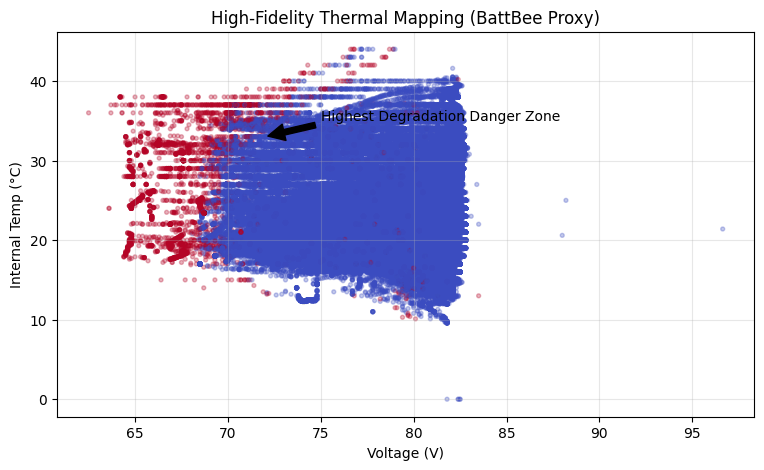

In [18]:
# Sample heavily for unsupervised clustering
therm_df = learning_fleet.dropna(subset=['vbt', 'vbv', 'vbc', 'soc']).copy()
therm_subset = therm_df.sample(min(250000, len(therm_df)), random_state=SEED)
X_therm_raw = therm_subset[['vbt', 'vbv', 'vbc', 'soc']]

iso = IsolationForest(n_estimators=150, contamination=0.015, random_state=SEED, n_jobs=-1)
# Note: Isolation forest deals better with normalized data
X_therm_scaled_iso = StandardScaler().fit_transform(X_therm_raw)

therm_subset['anomaly'] = iso.fit_predict(X_therm_scaled_iso)
therm_subset['anomaly'] = therm_subset['anomaly'].map({1: 0, -1: 1})

n_anom = therm_subset['anomaly'].sum()
print(f"Algorithm flagged {n_anom} extreme thermal events.")

# Plot bounds
plt.figure(figsize=(9,5))
plt.scatter(therm_subset['vbv'], therm_subset['vbt'], c=therm_subset['anomaly'], cmap='coolwarm', alpha=0.3, s=8)
plt.title("High-Fidelity Thermal Mapping (BattBee Proxy)")
plt.xlabel("Voltage (V)")
plt.ylabel("Internal Temp (°C)")
plt.annotate('Highest Degradation Danger Zone', xy=(72, 33), xytext=(75, 35),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(alpha=0.3)
plt.show()

import pickle
with open(os.path.join(MDL_DIR, 'thermal_isolation_v2.pkl'), 'wb') as f:
    pickle.dump(iso, f)

## 7. Results Dashboard

In [19]:
results_df = pd.DataFrame([
    {
        'Algorithm Architecture': 'DLinear (V2 Expanded)',
        'Validation Dataset': 'Temporal Split (Euler Fleet 2M)',
        'Target Hazard': 'End-of-Life SOH Extrapolation',
        'RMSE': f"{rmse_dl:.3f}%",
        'MAE': f"{mae_dl:.3f}%"
    },
    {
        'Algorithm Architecture': 'Hybrid CNN-LSTM (V2 Baseline)',
        'Validation Dataset': 'Temporal Split (Euler Fleet 2M)',
        'Target Hazard': 'End-of-Life SOH Extrapolation',
        'RMSE': f"{rmse_hyb:.3f}%",
        'MAE': f"{mae_hyb:.3f}%"
    },
    {
        'Algorithm Architecture': 'Isolation Forest',
        'Validation Dataset': 'Magenta Fleet Multi-modal',
        'Target Hazard': 'Localized Hotspots (Pre-TR Warning)',
        'RMSE': 'N/A',
        'MAE': f"Logged {(n_anom/len(therm_subset))*100:.2f}% fleet anomalies"
    }
])

pd.set_option('display.max_colwidth', None)
display(results_df)

print(f"\nAll models safely stored to: {MDL_DIR}")

,Algorithm Architecture,Validation Dataset,Target Hazard,RMSE,MAE
0,DLinear (V2 Expanded),Temporal Split (Euler Fleet 2M),End-of-Life SOH Extrapolation,8.326%,6.539%
1,Hybrid CNN-LSTM (V2 Baseline),Temporal Split (Euler Fleet 2M),End-of-Life SOH Extrapolation,5.098%,2.909%
2,Isolation Forest,Magenta Fleet Multi-modal,Localized Hotspots (Pre-TR Warning),N/A,Logged 1.45% fleet anomalies



All models safely stored to: /content/drive/MyDrive/FYP_Battery_Project/Models_v2_HighCapacity
